# 04 Business Clustring

Goal: cluster businesses by marketing behavior and performance to answer:
**"What type of marketer is this business?"**


In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from IPython.display import display
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)


## Load Data


In [261]:
DATA_PATH = r"C:\users\hanib\data_mining -project\marketing\data\processed\kpi_dataset.json"
#  C:\users\hanib\data_mining -project\marketing\data\processed\kpi_dataset.json
# C:\users\hanib\data_mining -project\marketing\data\data_processed.json

try:
    df = pd.read_json(DATA_PATH)
except ValueError:
    df = pd.read_json(DATA_PATH, lines=True)

print('Shape:', df.shape)
display(df.head(3))



Shape: (709, 42)


,business_name,sector,followers_count,post_date,day_of_week,month,post_type,caption_text,caption_length,hashtags_count,emoji_count,likes_count,comments_count,views_count,language,CTA_present,promo_post,mentions_location,religious_theme,patriotic_theme,arabic_dialect_style,sponsored,posting_hour,discount_percent,engagement,engagement_rate,like_rate,comment_rate,view_rate,view_engagement_rate,week,is_video,is_reel,posting_time_bin,caption_length_bin,hashtags_count_bin,emoji_count_bin,engagement_level,business_size_bin,high_engagement,high_view_rate,high_comment_rate
0,LOFT Palestine,Fashion,4392,1774915,Tuesday,1,reel,إطلالة أنثوية بلمسة عصرية ✨ من LOFT. للطلب الت...,88,0,2,13.0,0,1391,Arabic,True,False,True,False,False,True,0,0,0,13.0,0.002960,0.002960,0.000000,0.316712,0.009346,1969-12-29/1970-01-04,0,1,night,medium,none,few,medium,small,0,0,0
1,LOFT Palestine,Fashion,4392,1773792,Wednesday,1,reel,اختيارك المثالي لإطلالة كاجول مميزة 🤍✨ LOFT كو...,111,0,3,60.0,0,20300,Arabic,True,False,True,False,False,True,0,0,0,60.0,0.013661,0.013661,0.000000,4.622040,0.002956,1969-12-29/1970-01-04,0,1,night,medium,none,few,high,small,1,1,0
2,LOFT Palestine,Fashion,4392,1773619,Monday,1,reel,ستايل شبابي بلمسة عصرية له ولها ✨ اختيارات ممي...,133,0,2,250.0,4,52500,Arabic,True,False,True,False,False,True,0,0,0,254.0,0.057832,0.056922,0.000911,11.953552,0.004838,1969-12-29/1970-01-04,0,1,night,medium,none,few,high,small,1,1,1


## Simple EDA


In [262]:
print('Columns:')
print(df.columns.tolist())

print('Missing values:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing'))

print('Sector counts:')
display(df['sector'].value_counts(dropna=False).to_frame('posts_count'))

print('Post type counts:')
display(df['post_type'].value_counts(dropna=False).to_frame('posts_count'))


Columns:
['business_name', 'sector', 'followers_count', 'post_date', 'day_of_week', 'month', 'post_type', 'caption_text', 'caption_length', 'hashtags_count', 'emoji_count', 'likes_count', 'comments_count', 'views_count', 'language', 'CTA_present', 'promo_post', 'mentions_location', 'religious_theme', 'patriotic_theme', 'arabic_dialect_style', 'sponsored', 'posting_hour', 'discount_percent', 'engagement', 'engagement_rate', 'like_rate', 'comment_rate', 'view_rate', 'view_engagement_rate', 'week', 'is_video', 'is_reel', 'posting_time_bin', 'caption_length_bin', 'hashtags_count_bin', 'emoji_count_bin', 'engagement_level', 'business_size_bin', 'high_engagement', 'high_view_rate', 'high_comment_rate']
Missing values:


,missing
business_name,0
sector,0
followers_count,0
post_date,0
day_of_week,0
month,0
post_type,0
caption_text,0
caption_length,0
hashtags_count,0


Sector counts:


,posts_count
sector,
Fashion,281
Cafes/Restaurants,233
Influencers,80
Supermarkets,75
Gym,40


Post type counts:


,posts_count
post_type,
reel,594
post,115


## Prepare Business-Level Features


In [263]:
df = df[df["business_name"] != "Family Market PS"].copy()

work = df.copy()

# helper to normalize bool-like columns from mixed JSON values

def to_binary_flag(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (int, float)):
        return int(x != 0)
    t = str(x).strip().lower()
    if t in {'1','true','yes','y','on','present'}:
        return 1
    if t in {'0','false','no','n','off','none','nan',''}:
        return 0
    return 1

# numeric conversion
for c in ['followers_count','likes_count','comments_count','views_count','caption_length','hashtags_count','emoji_count','discount_percent' , 'engagement_rate','view_rate','comment_rate' , "engagement" , "post_date" ]:
    if c in work.columns:
        work[c] = pd.to_numeric(work[c], errors='coerce')
    else:
        work[c] = np.nan

# fill numeric missing with safe defaults
# work['followers_count'] = work['followers_count'].fillna(0)
# work['likes_count'] = work['likes_count'].fillna(0)
# work['comments_count'] = work['comments_count'].fillna(0)
# work['views_count'] = work['views_count'].fillna(0)
# work['caption_length'] = work['caption_length'].fillna(work['caption_length'].median())
# work['hashtags_count'] = work['hashtags_count'].fillna(0)
# work['emoji_count'] = work['emoji_count'].fillna(0)
# work['discount_percent'] = work['discount_percent'].fillna(0)

# binary columns
for c in ['CTA_present','promo_post','mentions_location','religious_theme','patriotic_theme','arabic_dialect_style']:
    if c in work.columns:
        work[c] = work[c].apply(to_binary_flag).astype(int)
    else:
        work[c] = 0

# post_type normalization
work['post_type'] = work['post_type'].astype(str).str.strip().str.lower()
work['post_type_std'] = np.select(
    [
        work['post_type'].str.contains('reel', na=False),
        work['post_type'].str.contains('carousel', na=False),
        work['post_type'].str.contains('image|photo|post', na=False),
    ],
    ['reel', 'carousel', 'image'],
    default='other'
)

# core rates at post-level
# work['engagement'] = work['likes_count'] + work['comments_count']
# work['engagement_rate'] = np.where(work['followers_count'] > 0, work['engagement'] / work['followers_count'], np.nan)
# work['view_rate'] = np.where(work['followers_count'] > 0, work['views_count'] / work['followers_count'], np.nan)
# work['comment_rate'] = np.where(work['followers_count'] > 0, work['comments_count'] / work['followers_count'], np.nan)

# date for posting frequency
work['post_date'] = pd.to_datetime(work.get('post_date'), errors='coerce')

# business aggregation
biz_base = (
    work.groupby(['business_name', 'sector'], dropna=False)
    .agg(
        followers_count=('followers_count', 'max'),
        posts_count=('business_name', 'size'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        avg_view_rate=('view_rate', 'mean'),
        avg_comment_rate=('comment_rate', 'mean'),
        avg_caption_length=('caption_length', 'mean'),
        avg_hashtags_count=('hashtags_count', 'mean'),
        avg_emoji_count=('emoji_count', 'mean'),
        percentage_promo_posts=('promo_post', 'mean'),
        percentage_CTA_posts=('CTA_present', 'mean'),
        percentage_location_posts=('mentions_location', 'mean'),
        percentage_religious_theme=('religious_theme', 'mean'),
        percentage_patriotic_theme=('patriotic_theme', 'mean'),
        percentage_arabic_dialect_style=('arabic_dialect_style', 'mean')
    )
    .reset_index()
)

# posting frequency (posts per active day)
active_days = (
    work.groupby('business_name')['post_date']
    .agg(lambda s: (s.max() - s.min()).days + 1 if s.notna().any() else np.nan)
    .rename('active_days')
)

biz = biz_base.merge(active_days, on='business_name', how='left')
biz['posting_frequency'] = np.where(biz['active_days'] > 0, biz['posts_count'] / biz['active_days'], np.nan)

# post type percentages
pt = pd.crosstab(work['business_name'], work['post_type_std'], normalize='index')
for c in ['reel', 'image', 'carousel']:
    if c not in pt.columns:
        pt[c] = 0
pt = pt[['reel','image','carousel']].rename(columns={
    'reel':'percentage_reels',
    'image':'percentage_images',
    'carousel':'percentage_carousels'
}).reset_index()

biz = biz.merge(pt, on='business_name', how='left')

# fill remaining nulls
for c in biz.columns:
    if biz[c].dtype.kind in 'biufc':
        med = biz[c].median()
        if pd.isna(med):
            med = 0
        biz[c] = biz[c].fillna(med)

# convert proportions to percentages for readability
pct_cols = [
    'percentage_reels','percentage_images','percentage_carousels',
    'percentage_promo_posts','percentage_CTA_posts','percentage_location_posts',
    'percentage_religious_theme','percentage_patriotic_theme','percentage_arabic_dialect_style'
]
for c in pct_cols:
    biz[c] = biz[c] * 100

print('Business rows:', len(biz))
display(biz.head(100))


Business rows: 67


,business_name,sector,followers_count,posts_count,avg_engagement_rate,avg_view_rate,avg_comment_rate,avg_caption_length,avg_hashtags_count,avg_emoji_count,percentage_promo_posts,percentage_CTA_posts,percentage_location_posts,percentage_religious_theme,percentage_patriotic_theme,percentage_arabic_dialect_style,active_days,posting_frequency,percentage_reels,percentage_images,percentage_carousels
0,528 Fashion,Fashion,4500,8,0.000278,0.149028,0.000000,166.500000,3.625,0.125,100.0,100.000000,100.000000,0.000000,0.0,100.000000,1,8.0,100.0,0.0,0
1,99streetwear,Fashion,5200,9,0.000577,0.826923,0.000064,115.444444,0.000,3.000,100.0,100.000000,100.000000,0.000000,0.0,100.000000,1,9.0,100.0,0.0,0
2,Abu shukri restaurant-مطعم حمص ابو شكري,Cafes/Restaurants,2900,3,0.024713,9.947701,0.005172,245.000000,0.000,0.000,0.0,0.000000,33.333333,33.333333,0.0,0.000000,1,3.0,0.0,100.0,0
3,Ahmed Sh Ajwa,Influencers,15000000,1,0.000297,0.019400,0.000010,103.000000,0.000,0.000,0.0,0.000000,100.000000,0.000000,100.0,100.000000,1,1.0,100.0,0.0,0
4,Al Jazeera English,Influencers,1100000,2,0.008791,0.154091,0.000132,145.000000,2.500,0.000,0.0,0.000000,100.000000,0.000000,100.0,0.000000,1,2.0,100.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,ahmedalhenawi1,Influencers,5700000,1,0.013258,0.473684,0.000135,28.000000,0.000,0.000,100.0,0.000000,0.000000,0.000000,0.0,100.000000,1,1.0,100.0,0.0,0
63,drift.for.men,Fashion,53500,4,0.002682,0.684584,0.000019,70.500000,1.000,0.250,100.0,25.000000,25.000000,0.000000,25.0,25.000000,1,4.0,100.0,0.0,0
64,جروان الدوار,Fashion,369000,14,0.000079,0.023945,0.000000,59.714286,0.000,0.000,100.0,100.000000,42.857143,0.000000,0.0,100.000000,1,14.0,100.0,0.0,0
65,متجر الأميرات للسيدات,Fashion,5600,12,0.006250,0.986503,0.000744,118.750000,0.000,9.500,100.0,100.000000,0.000000,75.000000,0.0,100.000000,1,12.0,100.0,0.0,0


## Feature Matrix For Clustering


In [264]:
biz['log_followers_count'] = np.log1p(biz['followers_count'])

feature_cols = [
    'log_followers_count',
    'avg_engagement_rate',
    'avg_view_rate',
    'avg_comment_rate',
    'posting_frequency',
    'avg_caption_length',
    'avg_hashtags_count',
    'avg_emoji_count',
    'percentage_reels',
    'percentage_images',
    'percentage_promo_posts',
    'percentage_CTA_posts',
    'percentage_location_posts',
    'percentage_religious_theme',
    'percentage_patriotic_theme',
    'percentage_arabic_dialect_style'
]

X = biz[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
for c in feature_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce')
    X[c] = X[c].fillna(X[c].median() if not pd.isna(X[c].median()) else 0)

print('Any NaN in X:', bool(X.isna().any().any()))
print('X shape:', X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 'avg_engagement_rate', avg_view_rate , 'avg_comment_rate'



Any NaN in X: False
X shape: (67, 16)


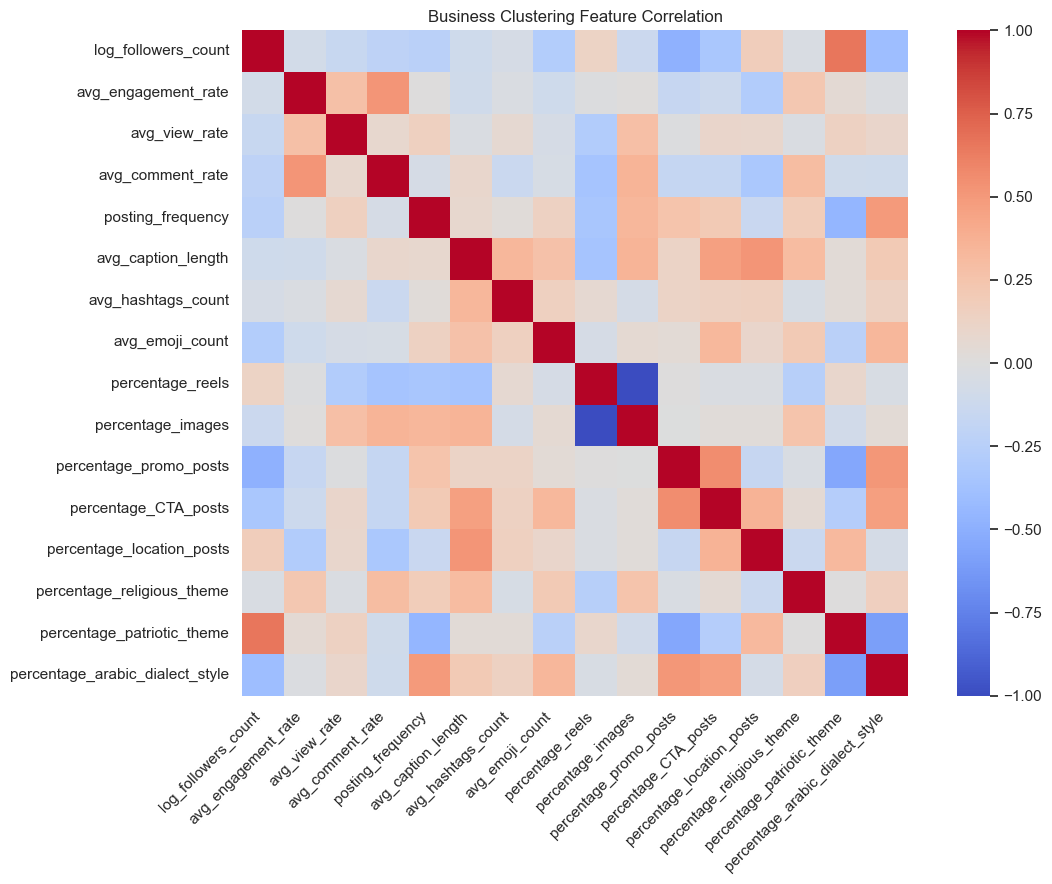

In [265]:
# Correlation table
corr = biz[feature_cols].corr(numeric_only=True)
# Correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    square=True
)
plt.title("Business Clustering Feature Correlation")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [266]:
display(biz[feature_cols].isna().sum().sort_values(ascending=False))
display(biz[feature_cols].nunique().sort_values())
display(biz[feature_cols].std(numeric_only=True).sort_values())


log_followers_count                0
avg_engagement_rate                0
avg_view_rate                      0
avg_comment_rate                   0
posting_frequency                  0
avg_caption_length                 0
avg_hashtags_count                 0
avg_emoji_count                    0
percentage_reels                   0
percentage_images                  0
percentage_promo_posts             0
percentage_CTA_posts               0
percentage_location_posts          0
percentage_religious_theme         0
percentage_patriotic_theme         0
percentage_arabic_dialect_style    0
dtype: int64

percentage_images                  12
percentage_reels                   12
percentage_patriotic_theme         14
percentage_arabic_dialect_style    16
posting_frequency                  21
percentage_promo_posts             21
percentage_religious_theme         22
percentage_location_posts          23
percentage_CTA_posts               26
avg_hashtags_count                 30
avg_emoji_count                    50
log_followers_count                50
avg_comment_rate                   61
avg_caption_length                 66
avg_engagement_rate                67
avg_view_rate                      67
dtype: int64

avg_comment_rate                    0.000725
avg_engagement_rate                 0.015263
avg_hashtags_count                  1.897427
log_followers_count                 2.649908
avg_emoji_count                     3.739419
posting_frequency                   7.247888
percentage_religious_theme         19.483580
percentage_images                  24.406507
percentage_reels                   24.406507
avg_view_rate                      27.888592
percentage_CTA_posts               38.369440
percentage_location_posts          39.297552
percentage_promo_posts             39.490359
percentage_patriotic_theme         40.412386
percentage_arabic_dialect_style    40.704307
avg_caption_length                 77.863318
dtype: float64

## KMeans (Elbow + Silhouette)


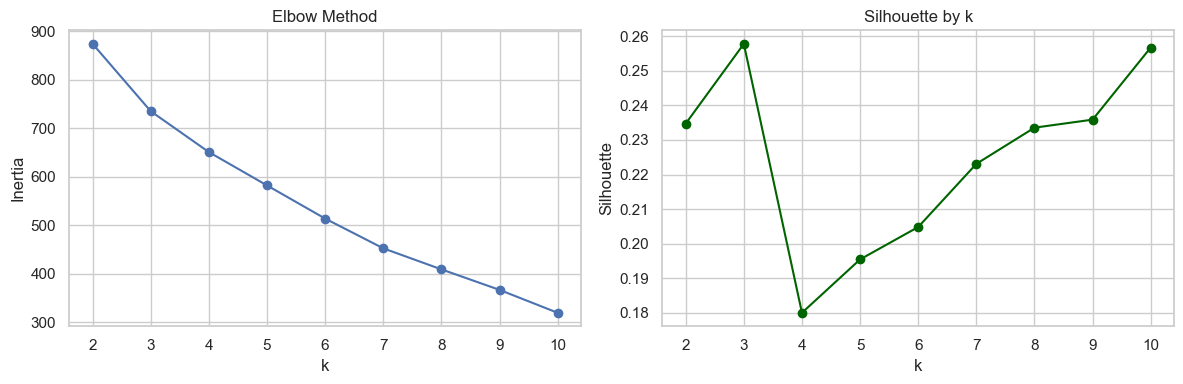

Best k (silhouette): 3


In [267]:
inertias = []
sils = []
K = range(2, min(11, len(X_scaled)))

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K), inertias, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')

ax[1].plot(list(K), sils, marker='o', color='darkgreen')
ax[1].set_title('Silhouette by k')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

best_k = list(K)[int(np.argmax(sils))]
print('Best k (silhouette):', best_k)


## Fit KMeans + t-SNE Visualization


KMeans cluster counts:


,business_count
kmeans_cluster,
0,11
1,41
2,15


Updated JSON with centroids: C:\users\hanib\data_mining -project\marketing\notebooks\clustering\artifacts\business_clustering\json\business_cluster_coordinates.json


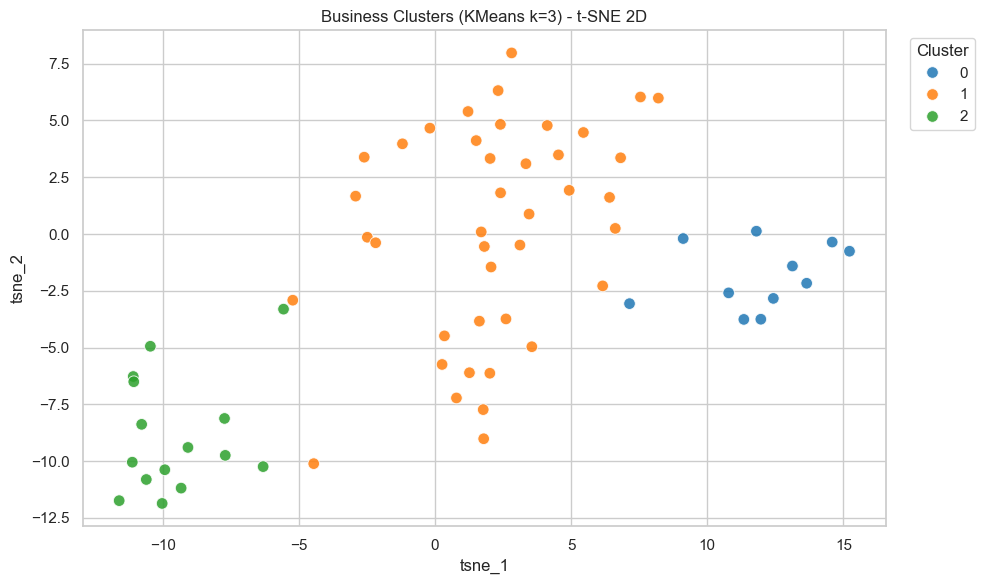

In [268]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=30)
biz['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('KMeans cluster counts:')
display(biz['kmeans_cluster'].value_counts().sort_index().to_frame('business_count'))

import json
from pathlib import Path
import pandas as pd

json_path = Path(r"C:\users\hanib\data_mining -project\marketing\notebooks\clustering\artifacts\business_clustering\json\business_cluster_coordinates.json")

# Requires existing objects from your notebook:
# feature_cols, scaler, kmeans

# Build centroid tables
centroids_scaled_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)
centroids_scaled_df.insert(0, "kmeans_cluster", range(len(centroids_scaled_df)))

centroids_original_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroids_original_df.insert(0, "kmeans_cluster", range(len(centroids_original_df)))

# Load existing JSON
payload = json.loads(json_path.read_text(encoding="utf-8"))

# Add centroids
payload["kmeans_centroids"] = {
    "feature_columns": feature_cols,
    "scaled_space": centroids_scaled_df.to_dict(orient="records"),
    "original_space": centroids_original_df.to_dict(orient="records")
}

# Save back
json_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Updated JSON with centroids: {json_path}")

# t-SNE 2D map for business visualization
perplexity = max(5, min(30, len(X_scaled)//5))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)


biz['tsne_1'] = X_tsne[:, 0]
biz['tsne_2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=biz, x='tsne_1', y='tsne_2', hue='kmeans_cluster', palette='tab10', s=70, alpha=0.85)
plt.title(f'Business Clusters (KMeans k={best_k}) - t-SNE 2D')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



## DBSCAN


{'eps': 3.1, 'min_samples': 4}
DBSCAN clusters: 3 | noise_ratio: 0.194 | silhouette_non_noise: 0.3174


,business_count
dbscan_cluster,
-1,13
0,36
1,12
2,6


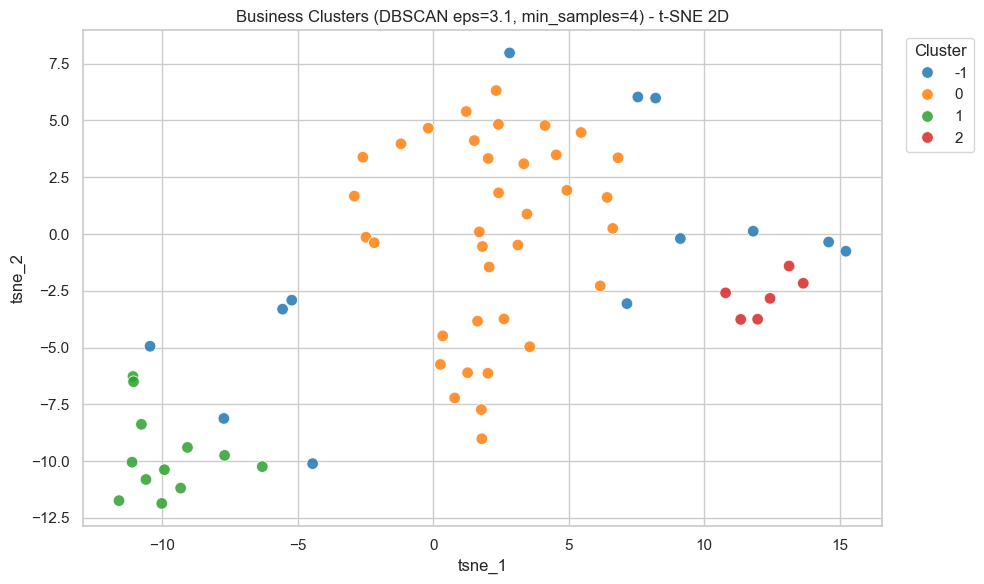

In [269]:
# Manual DBSCAN (set these by hand)
DBSCAN_EPS = 3.1
DBSCAN_MIN_SAMPLES = 4

db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
labels = db.fit_predict(X_scaled)

biz['dbscan_cluster'] = labels

n_clusters = len(set(labels) - {-1})
noise_ratio = float((labels == -1).mean())

sil = np.nan
mask = labels != -1
if n_clusters >= 2 and mask.sum() > n_clusters and len(np.unique(labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask])

print({'eps': DBSCAN_EPS, 'min_samples': DBSCAN_MIN_SAMPLES})
print('DBSCAN clusters:', n_clusters, '| noise_ratio:', round(noise_ratio, 3), '| silhouette_non_noise:', None if np.isnan(sil) else round(float(sil), 4))
display(biz['dbscan_cluster'].value_counts().sort_index().to_frame('business_count'))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=biz, x='tsne_1', y='tsne_2', hue='dbscan_cluster', palette='tab10', s=70, alpha=0.85)
plt.title(f"Business Clusters (DBSCAN eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}) - t-SNE 2D")
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Cluster Profiling + Sector Distribution


In [270]:
profile_cols = [
    'avg_engagement_rate','avg_view_rate','avg_comment_rate','posting_frequency',
    'avg_caption_length','avg_hashtags_count','avg_emoji_count',
    'percentage_reels','percentage_images','percentage_carousels',
    'percentage_promo_posts','percentage_CTA_posts','percentage_location_posts',
    'percentage_religious_theme','percentage_patriotic_theme','percentage_arabic_dialect_style'
]

kmeans_profile = biz.groupby('kmeans_cluster')[profile_cols].mean().round(3)
print('KMeans cluster profile:')
display(kmeans_profile)

print('KMeans sector distribution:')
kmeans_sector = pd.crosstab(biz['kmeans_cluster'], biz['sector'], normalize='index').round(3) * 100
display(kmeans_sector)

print('DBSCAN cluster profile (excluding noise -1):')
db_prof = biz[biz['dbscan_cluster'] != -1].groupby('dbscan_cluster')[profile_cols].mean().round(3)
display(db_prof)

print('DBSCAN sector distribution (excluding noise -1):')
db_sec = pd.crosstab(biz[biz['dbscan_cluster'] != -1]['dbscan_cluster'], biz[biz['dbscan_cluster'] != -1]['sector'], normalize='index').round(3) * 100
display(db_sec)


KMeans cluster profile:


,avg_engagement_rate,avg_view_rate,avg_comment_rate,posting_frequency,avg_caption_length,avg_hashtags_count,avg_emoji_count,percentage_reels,percentage_images,percentage_carousels,percentage_promo_posts,percentage_CTA_posts,percentage_location_posts,percentage_religious_theme,percentage_patriotic_theme,percentage_arabic_dialect_style
kmeans_cluster,,,,,,,,,,,,,,,,
0,0.008,21.687,0.001,17.818,186.130,0.580,2.973,37.674,62.326,0.0,72.693,62.398,56.314,21.579,19.450,73.888
1,0.008,2.499,0.000,10.951,126.800,1.225,3.030,98.916,1.084,0.0,87.566,68.584,52.336,10.172,3.808,86.083
2,0.011,0.502,0.000,3.200,122.504,0.437,0.323,100.000,0.000,0.0,23.667,34.222,77.000,12.556,92.667,18.333


KMeans sector distribution:


sector,Cafes/Restaurants,Fashion,Gym,Influencers,Supermarkets
kmeans_cluster,,,,,
0,100.0,0.0,0.0,0.0,0.0
1,7.3,68.3,7.3,4.9,12.2
2,0.0,0.0,0.0,100.0,0.0


DBSCAN cluster profile (excluding noise -1):


,avg_engagement_rate,avg_view_rate,avg_comment_rate,posting_frequency,avg_caption_length,avg_hashtags_count,avg_emoji_count,percentage_reels,percentage_images,percentage_carousels,percentage_promo_posts,percentage_CTA_posts,percentage_location_posts,percentage_religious_theme,percentage_patriotic_theme,percentage_arabic_dialect_style
dbscan_cluster,,,,,,,,,,,,,,,,
0,0.005,2.306,0.0,10.250,120.957,0.757,2.413,99.074,0.926,0.0,91.104,68.012,50.807,10.017,2.253,84.150
1,0.003,0.185,0.0,3.583,123.131,0.462,0.196,100.000,0.000,0.0,17.083,30.278,92.083,7.361,95.000,10.417
2,0.003,0.648,0.0,22.667,144.558,0.447,2.593,48.236,51.764,0.0,79.520,53.979,38.104,15.579,6.306,85.461


DBSCAN sector distribution (excluding noise -1):


sector,Cafes/Restaurants,Fashion,Gym,Influencers,Supermarkets
dbscan_cluster,,,,,
0,5.6,72.2,5.6,2.8,13.9
1,0.0,0.0,0.0,100.0,0.0
2,100.0,0.0,0.0,0.0,0.0


## Recommendation Template (Per Cluster)

- Cluster 0 — Active Sellers

They post a lot, use many reels, strong CTA, and many promo posts. Focus is to push people to act now.

-Cluster 1 — Community Voices

They post less, rarely use promo/CTA, but strongly use local/patriotic themes. Focus is identity and trust, not direct selling.

- Cluster 2 — Reach Chasers

They get high views, mostly reels, and use promo often. Focus is visibility and awareness more than deep engagement.
- Cluster 3 — Brand Storytellers

They mix reels and images, use longer captions and expressive style. Focus is brand feel and storytelling, softer selling.


## Save DBSCAN Artifacts For Inference

Save all objects needed to assign DBSCAN cluster to new businesses without retraining.


## DBSCAN Inference (No Retraining)

Inference rule: scale input, find training neighbors within `eps`; if neighbors >= `min_samples`, assign dominant non-noise label, else `-1`.


In [271]:
biz4 = biz[biz["dbscan_cluster"].isin([0, 1, 2, 3])].copy()

# Aggregate on your full business-clustering dataframe
cluster_report = biz4.groupby("dbscan_cluster").agg({
    "business_name": "nunique",
    "posts_count": ["mean", "median"],
    "avg_engagement_rate": ["mean", "median"],
    "avg_view_rate": ["mean", "median"],
    "followers_count": ["mean", "median"],
}).round(4)

display(cluster_report)

business_name posts_count        avg_engagement_rate          \
                     nunique        mean median                mean  median   
dbscan_cluster                                                                
0                         36     10.2500    9.5              0.0053  0.0028   
1                         12      3.5833    1.0              0.0035  0.0018   
2                          6     22.6667   24.5              0.0028  0.0023   

               avg_view_rate         followers_count             
                        mean  median            mean     median  
dbscan_cluster                                                   
0                     2.3057  0.4217    2.026195e+05    14000.0  
1                     0.1854  0.1230    5.733333e+06  1100000.0  
2                     0.6478  0.2727    7.183333e+04    43000.0

In [272]:
# Top 5 businesses per cluster by engagement rate
top5_per_cluster = (
    biz.sort_values(["dbscan_cluster", "avg_engagement_rate"], ascending=[True, False])
       .groupby("dbscan_cluster", as_index=False)
       .head(5)
)

display(top5_per_cluster[[
    "dbscan_cluster",
    "business_name",
    "sector",
    "avg_engagement_rate",
    "avg_view_rate",
    "posting_frequency",
    "followers_count"
    ]])



,dbscan_cluster,business_name,sector,avg_engagement_rate,avg_view_rate,posting_frequency,followers_count
24,-1,Hulk Gym / Diaa Shabaro,Gym,0.087666,9.396475,16.0,2404
42,-1,Nour Alsaqa,Influencers,0.079159,1.306364,2.0,1100000
49,-1,Robian Restaurant,Cafes/Restaurants,0.036354,222.500000,20.0,6500
11,-1,FPAIspal,Influencers,0.030255,3.822783,1.0,1100000
2,-1,Abu shukri restaurant-مطعم حمص ابو شكري,Cafes/Restaurants,0.024713,9.947701,3.0,2900
59,0,Xtreme Fitness Ramallah,Gym,0.019169,3.068359,8.0,4480
30,0,LOFT Palestine,Fashion,0.018329,57.760954,9.0,4392
35,0,Mazaj Oriental - مزاج الشرقي,Cafes/Restaurants,0.015546,0.542719,16.0,22800
36,0,Metro Market Nablus,Supermarkets,0.014409,1.393986,16.0,1748
62,0,ahmedalhenawi1,Influencers,0.013258,0.473684,1.0,5700000


In [273]:
# Compare only clusters 0 and 2 (using your notebook column names)
biz[biz["dbscan_cluster"].isin([0, 2])].groupby("dbscan_cluster").agg({
    "avg_engagement_rate": ["mean", "median"],
    "avg_view_rate": ["mean", "median"],
    "posts_count": ["mean", "median"],
    "followers_count": ["mean", "median"]
}).round(4)


avg_engagement_rate         avg_view_rate         posts_count  \
                              mean  median          mean  median        mean   
dbscan_cluster                                                                 
0                           0.0053  0.0028        2.3057  0.4217     10.2500   
2                           0.0028  0.0023        0.6478  0.2727     22.6667   

                      followers_count           
               median            mean   median  
dbscan_cluster                                  
0                 9.5     202619.5278  14000.0  
2                24.5      71833.3333  43000.0

In [274]:

print("cluster_id" in biz.columns, "avg_engagement_rate" in biz.columns)
print([c for c in biz.columns if "cluster" in c.lower() or "engagement" in c.lower()])

False True
['avg_engagement_rate', 'kmeans_cluster', 'dbscan_cluster']


In [275]:
# Per-KMeans-cluster averages for the 3 metrics you requested

cluster_avg = (
    biz.groupby("kmeans_cluster")[["avg_engagement_rate", "avg_view_rate", "avg_comment_rate" ]]
       .mean()
       .reset_index()
       .sort_values("kmeans_cluster")
)

print(cluster_avg)


   kmeans_cluster  avg_engagement_rate  avg_view_rate  avg_comment_rate
0               0             0.008015      21.687005          0.000664
1               1             0.007690       2.499218          0.000243
2               2             0.011021       0.501807          0.000249


In [276]:
biz.sort_values(["kmeans_cluster", "avg_engagement_rate"], ascending=[True, False]) \
   .groupby("kmeans_cluster").head(3)[["kmeans_cluster" , "business_name", "avg_engagement_rate", "followers_count", "sector"]] 

,kmeans_cluster,business_name,avg_engagement_rate,followers_count,sector
49,0,Robian Restaurant,0.036354,6500,Cafes/Restaurants
2,0,Abu shukri restaurant-مطعم حمص ابو شكري,0.024713,2900,Cafes/Restaurants
44,0,Pardo Cafe,0.007669,7400,Cafes/Restaurants
24,1,Hulk Gym / Diaa Shabaro,0.087666,2404,Gym
61,1,aburob,0.020731,5700000,Influencers
59,1,Xtreme Fitness Ramallah,0.019169,4480,Gym
42,2,Nour Alsaqa,0.079159,1100000,Influencers
11,2,FPAIspal,0.030255,1100000,Influencers
21,2,Hamdan ElDahdouh,0.014006,1100000,Influencers


| Cluster                                            | Meaning                                                                                                                                                                                                                                                                                                                                                                                    | Recommendation                                                                                                                                                                                                                                                                                                 |
| -------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Cluster 0 – Influencer / Media Reel Accounts**   | This cluster contains mostly influencer and media-style accounts with very large follower counts and fully reel-based content. High-performing accounts in this cluster achieve stronger engagement through more emotionally engaging content rather than relying only on patriotic or location-heavy themes.                                                                              | Focus on more engaging storytelling, personal-style reels, and emotionally driven content. Reduce over-reliance on repetitive patriotic/location content. Best posting days appear to be Tuesday, Wednesday, and Thursday.                                                                                     |
| **Cluster 1 – Mixed Commercial Business Baseline** | This cluster represents the general business baseline and includes fashion pages, gyms, restaurants, and some influencers. Accounts in this cluster rely heavily on reels and promotional content, but performance differs depending on content quality and hashtag usage. High-performing businesses achieve much better reach while using slightly less aggressive promotional behavior. | Continue using reels as the main content type, but improve content quality instead of only increasing promotional posts. Use stronger visual hooks, clearer captions, and better hashtag strategies. Focus more on posting during Monday, Wednesday, Thursday, and Saturday.                                   |
| **Cluster 2 – Restaurant / Cafe Content Cluster**  | This cluster contains mostly restaurant and cafe pages. The content strategy is more visually oriented, using a mixture of images and reels with high promotional activity. High-performing accounts in this cluster tend to use shorter captions and less aggressive promotional style while still maintaining strong visual appeal.                                                      | Restaurants and cafes should reduce very long promotional captions and focus more on visually appealing food content. Test high-quality image posts alongside reels, since image-based posts showed strong performance in this cluster. Best posting days appear to be Tuesday, Sunday, Friday, and Wednesday. |


In [277]:
biz_name = "Vanilla Palestine"

vanilla_rates = (
    work.loc[work["business_name"].astype(str).str.lower() == biz_name.lower(),
             ["engagement_rate", "view_rate", "comment_rate"]]
    .apply(pd.to_numeric, errors="coerce")
    .mean()
    .rename({
        "engagement_rate": "avg_engagement_rate",
        "view_rate": "avg_view_rate",
        "comment_rate": "avg_comment_rate",
    })
)

print(vanilla_rates.to_string())


avg_engagement_rate    0.005619
avg_view_rate          0.474398
avg_comment_rate       0.000034


In [278]:
print(vanilla_rates.to_frame().T.to_string(index=False))


 avg_engagement_rate  avg_view_rate  avg_comment_rate
            0.005619       0.474398          0.000034


In [279]:
biz.loc[
    biz["business_name"].astype(str).str.lower().eq("vanilla palestine"),
    ["business_name", "kmeans_cluster"]
]

,business_name,kmeans_cluster
55,Vanilla Palestine,0
